In [99]:
import os
import pandas as pd 
import numpy as np 

### Training data Preprocessing

In [86]:
data_train_path = "../data/original_data/churn_train.csv"
data_test_path = "../data/original_data/churn_test.csv"

train_data = pd.read_csv(data_train_path)
print(f"training data: {train_data.head()}")

test_data = pd.read_csv(data_test_path)
print(f"Testing data : {test_data.head()}")

training data:   State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1      

In [100]:
train_data['Churn'].unique()

array([False,  True])

In [87]:
## columns in data
print(f"Traing columns : {train_data.columns}")
print(f"Testing Columns : {test_data.columns}")

Traing columns : Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')
Testing Columns : Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')


In [88]:
col_char = ['State', 'International plan', 'Voice mail plan']
train_data.drop(col_char, axis = 1)

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,79,415,0,134.7,98,22.90,189.7,68,16.12,221.4,128,9.96,11.8,5,3.19,2,False
2662,192,415,36,156.2,77,26.55,215.5,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
2663,68,415,0,231.1,57,39.29,153.4,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
2664,28,510,0,180.8,109,30.74,288.8,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False


In [89]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [90]:
## null values

train_data.isna().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [91]:
test_data.isna().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [92]:
### no missing values in training as well as testing data

In [93]:
train_data.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

In [94]:
np.quantile(train_data['Area code'],0.25)

408.0

In [ ]:
## outliers
def find_outliers(df,col):
    if col == 'Churn':
        cont
    d = df[col]
    if d.dtype == "bool" or d.dtype == "object":
        return 0
    q1 = np.quantile(d,0.25)
    q3 = np.quantile(d, 0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    if (d < lower).any() or (d > upper).any():
        df[col] = np.log1p(df[col])
        print(1)

SyntaxError: 'continue' not properly in loop (3499036914.py, line 4)

In [11]:
for col in train_data.columns:
    print(find_outliers(train_data, col))

0
1
None
None
0
0
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
0


In [12]:
for col in test_data.columns:
    print(find_outliers(test_data, col))

0
1
None
1
None
0
0
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
1
None
0


In [13]:
import matplotlib.pyplot as plt
import seaborn

In [14]:
train_data['Churn']

0       False
1       False
2       False
3       False
4       False
        ...  
2661    False
2662    False
2663    False
2664    False
2665    False
Name: Churn, Length: 2666, dtype: bool

In [71]:
def missing_values(df):
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if df[col].dtype == "object":
                df[col].fillna(df[col].mode()[0], inplace = True)
            elif df[col].dtype == 'bool':
                print(col)
            else:
                df[col].fillna(df[col].mean(), inplace = True)


missing_values(train_data)

In [16]:
## outliers
def find_outliers(df,col):
    d = df[col]
    if d.dtype == "bool" or d.dtype == "object":
        return 0
    q1 = np.quantile(d,0.25)
    q3 = np.quantile(d, 0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    if (d < lower).any() or (d > upper).any():
        df[col] = np.log1p(df[col])
        print(1)

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

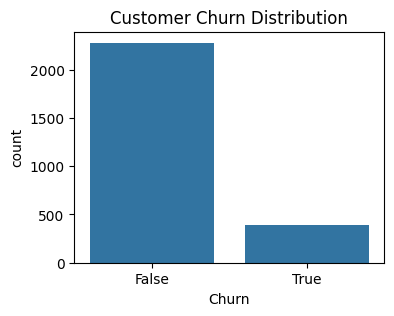

In [73]:

plt.figure(figsize=(4,3))
sns.countplot(x="Churn", data=train_data)

plt.title("Customer Churn Distribution")
plt.show()

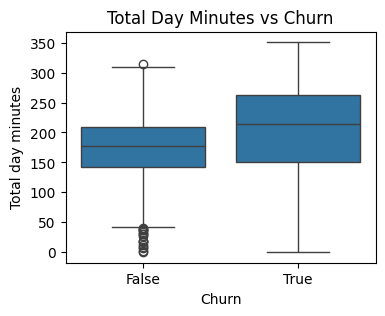

In [74]:
plt.figure(figsize=(4,3))
sns.boxplot(x="Churn", y="Total day minutes", data=train_data)

plt.title("Total Day Minutes vs Churn")
plt.show()

In [103]:
test_data["Churn"] = test_data['Churn'].map({True:1,False:0})

In [102]:
train_data['Churn'].unique()

array([0, 1], dtype=int64)

In [76]:
train_data.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

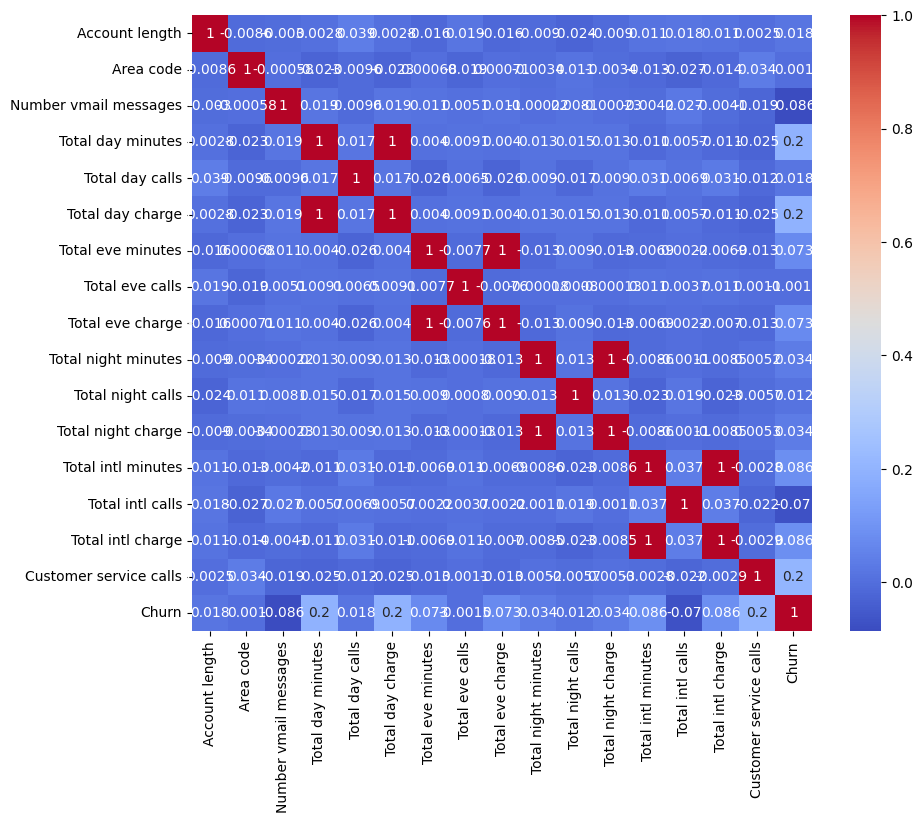

In [77]:
plt.figure(figsize=(10,8))

sns.heatmap(train_data.drop(col_char, axis = 1).corr(), annot=True, cmap="coolwarm")

plt.show()

In [37]:
train_data.to_csv("train_preprocessed.csv")

In [46]:
train_data

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,4.859812,415,No,Yes,3.258097,5.583872,4.709530,3.830162,5.290285,4.605170,2.878074,5.504111,4.521789,2.485740,2.397895,1.386294,1.308333,0.693147,0
1,OH,4.682131,415,No,Yes,3.295837,5.091293,4.820282,3.348851,5.280662,4.644391,2.869035,5.542831,4.644391,2.521721,2.687847,1.386294,1.547563,0.693147,0
2,NJ,4.927254,415,No,No,0.000000,5.498806,4.744932,3.746677,4.805659,4.709530,2.424803,5.097424,4.653960,2.118662,2.580217,1.791759,1.456287,0.000000,0
3,OH,4.442651,408,Yes,No,0.000000,5.705115,4.276666,3.949319,4.141546,4.488636,1.834180,5.287762,4.499810,2.288486,2.028148,2.079442,1.022451,1.098612,0
4,OK,4.330733,415,Yes,No,0.000000,5.122177,4.736198,3.378952,5.005958,4.812184,2.610805,5.235910,4.804021,2.241773,2.406945,1.386294,1.316408,1.386294,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,4.382027,415,No,No,0.000000,4.910447,4.595120,3.173878,5.250702,4.234107,2.840247,5.404478,4.859812,2.394252,2.549445,1.791759,1.432701,1.098612,0
2662,AZ,5.262690,415,No,Yes,3.610918,5.057519,4.356709,3.316003,5.377591,4.844187,2.961141,5.635147,4.430817,2.607124,2.388763,1.945910,1.300192,1.098612,0
2663,WV,4.234107,415,No,No,0.000000,5.447168,4.060443,3.696103,5.039547,4.025352,2.641910,5.259057,4.820282,2.262804,2.360854,1.609438,1.278152,1.386294,0
2664,RI,3.367296,510,No,No,0.000000,5.202907,4.700480,3.457578,5.669191,4.077537,3.240637,5.262172,4.521789,2.265921,2.714695,1.945910,1.570697,1.098612,0


In [78]:
def find_outliers(df):
    for col in df.columns:
        d = df[col]
        if d.dtype == "bool" or d.dtype == "object":
            continue
        q1 = np.quantile(d,0.25)
        q3 = np.quantile(d, 0.75)
        IQR = q3 - q1
        lower = q1 - 1.5 * IQR
        upper = q3 + 1.5 * IQR
        if (d < lower).any() or (d > upper).any():
            df[col] = np.log1p(df[col])
    return df

In [79]:
train_data = find_outliers(train_data)
test_data = find_outliers(test_data)

In [104]:

def missing_values(df):
    for col in df.columns:
        if df[col].isna().sum() > 0:
            if df[col].dtype == "object":
                df[col].fillna(df[col].mode()[0], inplace = True)
            elif df[col].dtype == 'bool':
                continue
            else:
                df[col].fillna(df[col].mean(), inplace = True)
    return df


## Outliers detection and log transformation

def find_outliers(df):
    for col in df.columns:
        if col == 'Churn':
            continue
        
        d = df[col]
        if d.dtype == "bool" or d.dtype == "object":
            continue
        q1 = np.quantile(d,0.25)
        q3 = np.quantile(d, 0.75)
        IQR = q3 - q1
        lower = q1 - 1.5 * IQR
        upper = q3 + 1.5 * IQR
        if (d < lower).any() or (d > upper).any():
            df[col] = np.log1p(df[col])

    return df

def preprocessed_data(df):
    df = missing_values(df)
    df = find_outliers(df)
    df = df.drop_duplicates()
    return df

In [107]:
train_data['Churn'].unique()

array([0, 1], dtype=int64)

In [115]:
train_data = preprocessed_data(train_data)

In [116]:
test_data = preprocessed_data(test_data)

In [117]:
train_data.to_csv("../data/processed_data/train_preprocessed.csv")


In [118]:
test_data.to_csv("../data/processed_data/test_preprocessed.csv")


In [119]:
train_data['Churn'].unique()

array([0, 1], dtype=int64)